In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from go_ml.eval_utils import filter_annot_df
from go_ml.eval_utils import (load_msa_dict, gen_bert_mat, get_bert_entropy, 
                              gen_annot_mat, gen_seq_len_mask, mean_reciprocal_rank, 
                              mean_reciprocal_rank_mat, mean_auc, top_30_score, roc_average)

data_root = '/home/andrew/GO_interp/go_ml/gen_datasets/datasets'
# csa_df = filter_annot_df(pd.read_csv(f'{data_root}/csa_annot.csv', sep='\t'))
# llps_df = filter_annot_df(pd.read_csv(f'{data_root}/llps_dataset.csv', sep='\t'))
# elms_df = filter_annot_df(pd.read_csv(f'{data_root}/elms_dataset.csv', sep='\t'))
dataset_labels = ['csa', 'ip_domain']
dataset_dfs = [filter_annot_df(pd.read_csv(f'{data_root}/{label}_dataset.csv', sep='\t')) for label in dataset_labels]

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from esm.models.esmc import ESMC
device = torch.device('cuda:0')
model = ESMC.from_pretrained("esmc_600m").to(device) # or "cpu"
model.eval()
vi = {i: a for a, i in model.tokenizer.get_vocab().items()}
AA_str = [vi[i] for i in range(4, 24)]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
from go_ml.masking import mask_perc, mask_indiv, mask_indiv_neighborhood
def iter_mask_func():
    res_cov = [1, 6, 12]
    mut_percs = [0.05, 0.15, 0.30]
    for mut_perc in mut_percs:
        for res_c in res_cov:
            mask_func = lambda seq, mask_token: mask_perc(seq, mask_token, mut_per=mut_perc, residue_coverage=res_c)
            yield f"mask_perc_{mut_perc}_{res_c}", mask_func
    yield "mask_indiv", mask_indiv
    # yield "mask_indiv_neighborhood_5", lambda seq, mask_token: mask_indiv_neighborhood(seq, mask_token, n_rad=5)

In [ ]:
from tqdm.notebook import tqdm
import pickle
import os
from go_ml.masking import get_logits_esmc

for ds_label, annot_df in zip(dataset_labels, dataset_dfs):
    # if ds_label not in ['ip_repeat', 'ip_homologous_superfamily', 'ip_family', 'ip_domain']:
    #     continue
    for mask_label, mask_func in iter_mask_func():
        print(f'Processing {ds_label}, {mask_label}')
        fp = f'/home/andrew/GO_interp/go_ml/dataset_eval/mask_eval_files/{ds_label}/{mask_label}_esmc.pkl'
        if(os.path.exists(fp)):
            print(f'Skipping {ds_label}, already done')
            continue
        df_logits = {}
        for i, (seq_id, seq) in tqdm(enumerate(zip(annot_df['UniprotID'], annot_df['Sequence'])), 
                                    total=len(annot_df), desc=f'Processing {ds_label}'):
            df_logits[seq_id] = get_logits_esmc(seq, model, batch_size=24, mask_func=mask_func).float()
        bert_map = {k: v[:, 4:24] for k, v in df_logits.items()}
        bert_map = {k: v / (v.sum(dim=1, keepdims=True) + 1e-10) for k, v in bert_map.items()}
        bert_map = {k: v.numpy() for k, v in bert_map.items()}

        annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
        seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
        bert_mat = gen_bert_mat(annot_df['UniprotID'], bert_map, max_len=850)
        bert_entropy = get_bert_entropy(bert_mat, seq_len_mask)
        with open(fp, 'wb') as f:
                pickle.dump({'UniprotID': annot_df['UniprotID'], 'bert_mat': bert_mat, 
                            'seq_len_mask': seq_len_mask, 'bert_entropy': bert_entropy}, f)
        print(f'DS label: {ds_label}, Mask label: {mask_label}, Done')

In [6]:
import os
import pandas as pd
import numpy as np
from go_ml.eval_utils import (gen_annot_mat, gen_seq_len_mask,
                              mean_reciprocal_rank, mean_reciprocal_rank_mat,
                                mean_auc, top_30_score, roc_average, bulk_auc)
from go_ml.eval_utils import filter_annot_df
from go_ml.data_utils import ProtFuncDataset
data_root = '/home/andrew/GO_interp/go_ml/gen_datasets/datasets'
dataset_labels = ['csa', 'ip_domain']
dataset_dfs = [filter_annot_df(pd.read_csv(f'{data_root}/{label}_dataset.csv', sep='\t')) for label in dataset_labels]
eval_dict = {}

df_rows = []
import pickle
for ds_label, annot_df in zip(dataset_labels, dataset_dfs):
    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    eval_dict[ds_label] = {'annot_mat': annot_mat, 'seq_len_mask': seq_len_mask}

In [9]:
import regex as re
def parse_filename(fp, ds_labels):
    save_str = fp.split('.pkl')[0]
    model_name = save_str
    return ds_label, model_name

#iterate through directories in masked_eval_files
for ds_label in os.listdir('mask_eval_files'):
    if not os.path.isdir(f'mask_eval_files/{ds_label}'):
        continue
    for fp in os.listdir(f'mask_eval_files/{ds_label}'):
        if not fp.endswith('.pkl'):
            continue
        save_str = fp.split('.pkl')[0]
        _, model_name = parse_filename(fp, dataset_labels)
        if ds_label is None or model_name is None:
            print(f"Warning: could not parse filename {fp}")
            continue
        with open(f'mask_eval_files/{ds_label}/{fp}', 'rb') as f:
            pred_dict = pickle.load(f)
        eval_dict[ds_label][model_name] = pred_dict

In [11]:
eval_dict['csa'].keys()

dict_keys(['annot_mat', 'seq_len_mask', 'mask_perc_0.05_6_esmc', 'mask_perc_0.3_6_esmc', 'mask_perc_0.05_12_esmc', 'mask_perc_0.15_1_esmc', 'mask_perc_0.15_12_esmc', 'mask_perc_0.05_1_esmc', 'mask_indiv_esmc', 'mask_indiv_neighborhood_5_esmc', 'mask_perc_0.15_6_esmc', 'mask_perc_0.3_12_esmc', 'mask_perc_0.3_1_esmc'])

In [15]:
import numpy as np
result_dict = {ds_label: {} for ds_label in eval_dict.keys()}
ds_score_dict = {}
for ds_label in eval_dict.keys():
    row = eval_dict[ds_label]
    mask = np.ones(len(row['annot_mat']), dtype=bool)
    annot_mat = row['annot_mat'][mask]
    seq_len_mask = row['seq_len_mask'][mask]

    score_dict = {}
    for mask_label in row.keys():
        if(mask_label in ['annot_mat', 'seq_len_mask', 'seq_ind']):
            continue
        print(f"Processing {ds_label}, {mask_label}")
        bert_entropy = row[mask_label]['bert_entropy'][mask]
        score_dict[f"{mask_label}_bert_entropy"] = 3 - bert_entropy
    score_dict['naive'] = np.random.random(bert_entropy.shape)
    # seq_ind = row['seq_ind'][mask]

    ds_score_dict[ds_label] = score_dict

    for annot_name, score_mat in score_dict.items():
        mrr = mean_reciprocal_rank_mat(score_mat, seq_len_mask, annot_mat)
        auc, (fpr_l, tpr_l, auc_l) = mean_auc(score_mat, seq_len_mask, annot_mat, return_roc=True)

        top30 = top_30_score(score_mat, seq_len_mask, annot_mat)
        result_dict[ds_label][annot_name] = {
            'MRR': mrr,
            'AUC': auc,
            'Top30': top30,
            'FPR': fpr_l,
            'TPR': tpr_l,
            'AUCs': auc_l
        }
        # (auc, fpr_l, tpr_l, mrr, top30, auc_l)
        bauc = bulk_auc(score_mat, seq_len_mask, annot_mat)
        print(f"Dataset: {ds_label} {annot_name}, MRR: {mrr:.4f}, AUC: {auc:.4f}, BAUC: {bauc:.4f}, Top-30 Score: {top30:.4f}")
    print()

Processing csa, mask_perc_0.05_6_esmc
Processing csa, mask_perc_0.3_6_esmc
Processing csa, mask_perc_0.05_12_esmc
Processing csa, mask_perc_0.15_1_esmc
Processing csa, mask_perc_0.15_12_esmc
Processing csa, mask_perc_0.05_1_esmc
Processing csa, mask_indiv_esmc
Processing csa, mask_indiv_neighborhood_5_esmc
Processing csa, mask_perc_0.15_6_esmc
Processing csa, mask_perc_0.3_12_esmc
Processing csa, mask_perc_0.3_1_esmc
Dataset: csa mask_perc_0.05_6_esmc_bert_entropy, MRR: 0.4100, AUC: 0.8147, BAUC: 0.7954, Top-30 Score: 0.5940
Dataset: csa mask_perc_0.3_6_esmc_bert_entropy, MRR: 0.4112, AUC: 0.8145, BAUC: 0.7917, Top-30 Score: 0.5913
Dataset: csa mask_perc_0.05_12_esmc_bert_entropy, MRR: 0.4091, AUC: 0.8153, BAUC: 0.7956, Top-30 Score: 0.5961
Dataset: csa mask_perc_0.15_1_esmc_bert_entropy, MRR: 0.0401, AUC: 0.7308, BAUC: 0.7173, Top-30 Score: 0.1160
Dataset: csa mask_perc_0.15_12_esmc_bert_entropy, MRR: 0.4130, AUC: 0.8158, BAUC: 0.7952, Top-30 Score: 0.5970
Dataset: csa mask_perc_0.05_

In [ ]:
from esm.sdk.api import ESMProtein, LogitsConfig
from esm.utils.constants.esm3 import (
    SEQUENCE_MASK_TOKEN,
)
annot_df = dataset_dfs[0]
seq_id, seq = next(iter(zip(annot_df['UniprotID'], annot_df['Sequence'])))
seq_ind = model.encode(ESMProtein(sequence=seq)).sequence

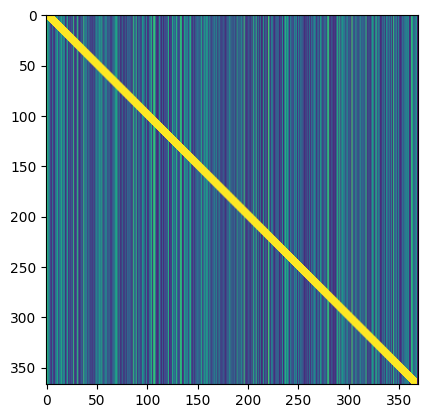

In [22]:
# batch, batch_inds, mut_inds = mask_indiv(seq_ind, mask_token=SEQUENCE_MASK_TOKEN)
# plt.imshow(batch.cpu().numpy())
batch, batch_inds, mut_inds = mask_indiv_neighborhood(seq_ind, mask_token=SEQUENCE_MASK_TOKEN, n_rad=5)
plt.imshow(batch.cpu().numpy())

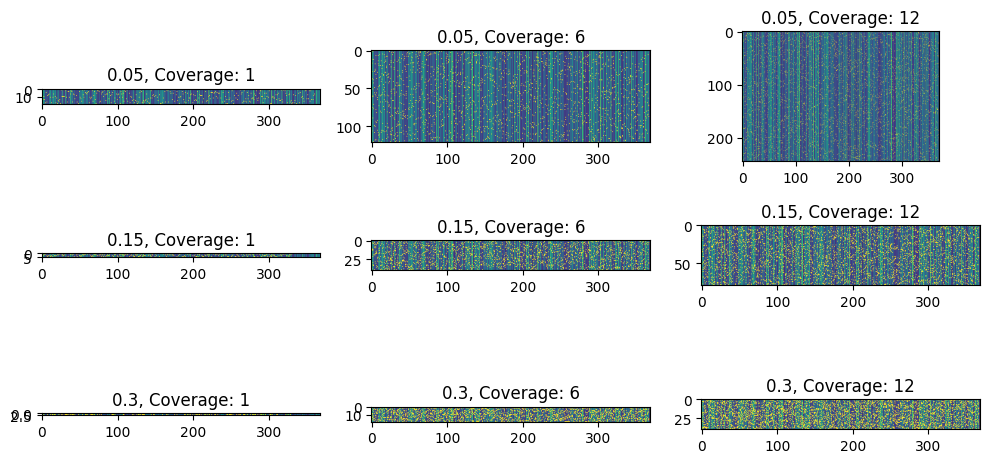

In [19]:
mut_percs = [0.05, 0.15, 0.30]
coverage_levels = [1, 6, 12]
fig, axes = plt.subplots(3, 3, figsize=(10, 5))
for i, perc in enumerate(mut_percs):
    for j, cov in enumerate(coverage_levels):
        batch, batch_inds, mut_inds = mask_perc(seq_ind, SEQUENCE_MASK_TOKEN, mut_per=perc, residue_coverage=cov)
        axes[i, j].imshow(batch.cpu().numpy())
        axes[i, j].set_title(f"{perc}, Coverage: {cov}")
fig.tight_layout()

In [ ]:
seq_id, seq = next(iter(zip(annot_df['UniprotID'], annot_df['Sequence'])))
seq_logits = get_logits_esmc(seq, model, batch_size=24, mask_func=mask_perc).float()
seq_probs = seq_logits[:, 4:24]